In [1]:
import pandas as pd
import json
import joblib
import matplotlib.pyplot as plt

results = pd.read_csv("../results/predictions.csv", index_col=0, parse_dates=True)

with open("../results/metrics.json") as f:
    metrics = json.load(f)

with open("../results/feature_names.json") as f:
    feature_names = json.load(f)

ridge_regr = joblib.load("../results/ridge_model.pkl")
rf_regr = joblib.load("../results/rf_model.pkl")

In [2]:
metrics_df = pd.DataFrame(
    {
        "MAE": {
            "Baseline": metrics["baseline"]["mae"],
            "Ridge": metrics["ridge"]["mae"],
            "Random Forest": metrics["rf"]["mae"],
        },
        "MSE": {
            "Baseline": metrics["baseline"]["mse"],
            "Ridge": metrics["ridge"]["mse"],
            "Random Forest": metrics["rf"]["mse"],
        },
    }
)

metrics_df

,MAE,MSE
Baseline,0.007594,0.000107
Ridge,0.007557,0.000118
Random Forest,0.006863,0.000098


In [3]:
results.head()

,actual,baseline_pred,ridge_pred,rf_pred
Date,,,,
2021-10-20,0.016855,0.010484,0.007822,0.013239
2021-10-21,0.015065,0.009879,0.007384,0.013529
2021-10-22,0.013815,0.011066,0.011361,0.013708
2021-10-25,0.014096,0.011237,0.010888,0.013929
2021-10-26,0.012970,0.010851,0.011447,0.013082


In [4]:
results.describe()

,actual,baseline_pred,ridge_pred,rf_pred
count,1051.000000,1051.000000,1051.000000,1051.000000
mean,0.020975,0.022065,0.021174,0.020661
std,0.010466,0.008134,0.007488,0.006257
min,0.004608,0.009879,0.007384,0.010967
25%,0.013537,0.015925,0.015895,0.016092
50%,0.018960,0.020764,0.019826,0.019094
75%,0.025850,0.025605,0.025139,0.023644
max,0.078698,0.057401,0.054802,0.078599


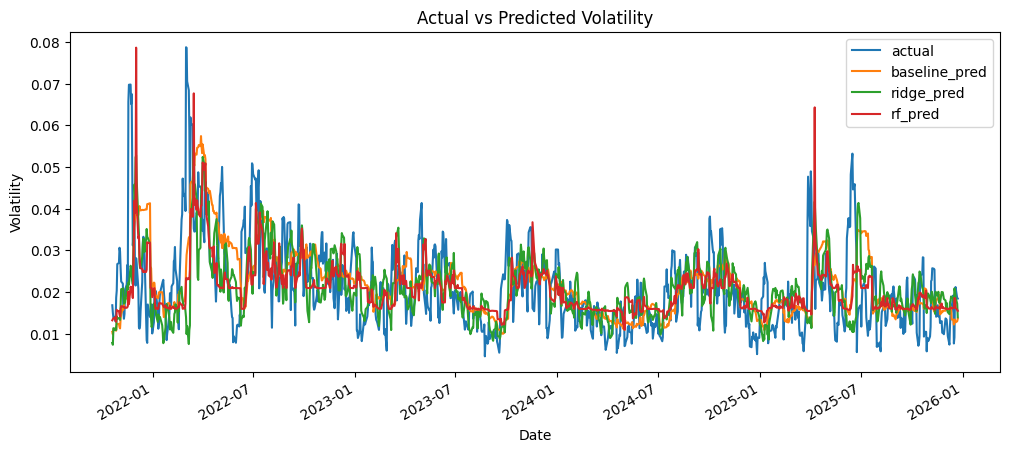

In [5]:
results[["actual", "baseline_pred", "ridge_pred", "rf_pred"]].plot(figsize=(12, 5))
plt.title("Actual vs Predicted Volatility")
plt.ylabel("Volatility")
plt.show()

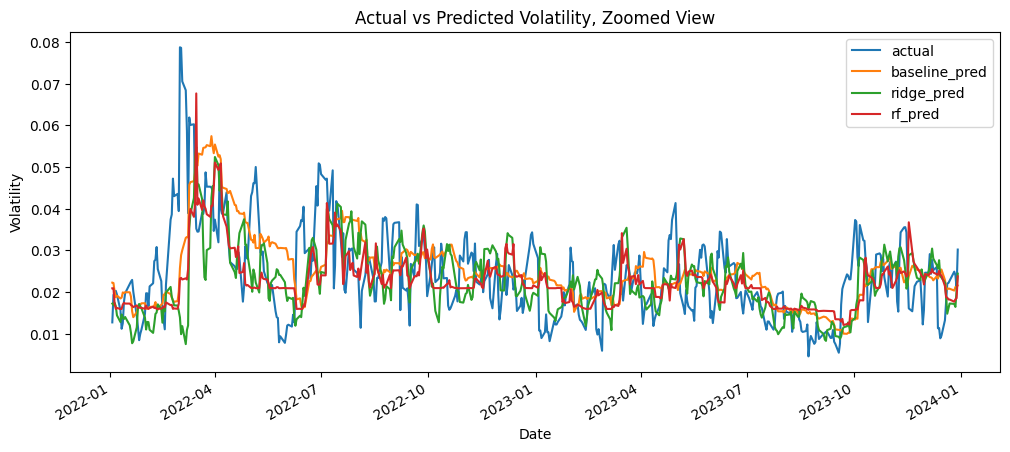

In [6]:
subset = results.loc["2022":"2023"]
subset[["actual", "baseline_pred", "ridge_pred", "rf_pred"]].plot(figsize=(12, 5))
plt.title("Actual vs Predicted Volatility, Zoomed View")
plt.ylabel("Volatility")
plt.show()

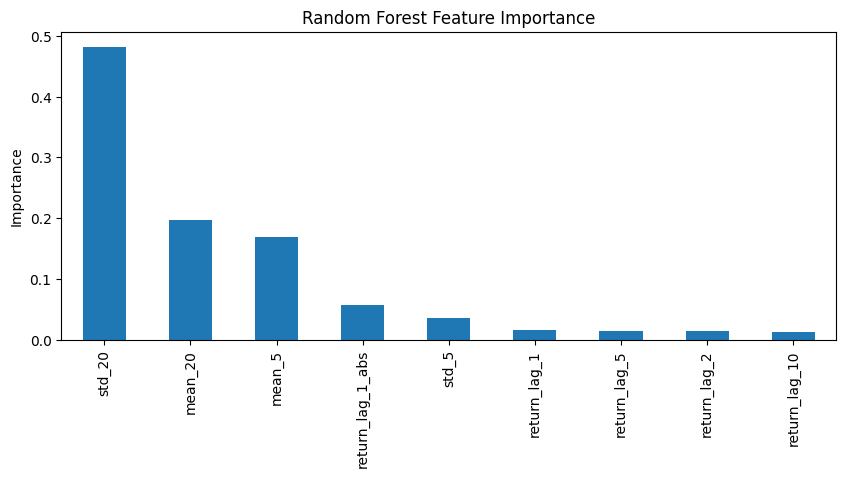

In [10]:
importance = pd.Series(rf_regr.feature_importances_, index=feature_names)
importance = importance.sort_values(ascending=False)

importance.plot(kind="bar", figsize=(10, 4))
plt.title("Random Forest Feature Importance")
plt.ylabel("Importance")
plt.show()

# Conclusions

This project studied short-term volatility prediction in financial time series using statistical features and machine learning models, with WTI crude oil used as a case study.

The results show that a simple persistence-based baseline, using recent volatility, already provides strong predictive performance. This is consistent with volatility clustering: periods of high volatility tend to be followed by high volatility, and vice versa.

Both Ridge regression and Random Forest achieve modest but consistent improvements over the baseline. The gains remain small, indicating that most of the predictive signal is already captured by past volatility. Random Forest slightly outperforms the linear model, suggesting limited nonlinear effects and feature interactions.

Feature importance analysis supports this interpretation. Long-horizon volatility is the dominant predictor, while short-horizon volatility and rolling mean features provide secondary information. Lagged returns contribute little, indicating that return direction has limited value for short-term volatility prediction.

Overall, the findings suggest that volatility dynamics are driven primarily by persistence, with machine learning adding only small incremental improvements. These results indicate that simple statistical structure explains most of the signal, while more flexible models mainly refine, rather than replace, the persistence-based approach.